# PAN 2025 AI-Generated Text Detection: Exploratory Data Analysis

This notebook analyzes the PAN 2025 AI-generated text detection dataset. We aim to understand data characteristics, identify distinguishing patterns between human and AI text (including token distributions), and derive insights for model development.


## 1. Setup and Basic Analysis

In [29]:
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path
import re
import warnings
from transformers import AutoTokenizer
from scipy.spatial.distance import jensenshannon

from nltk import tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.probability import FreqDist
warnings.filterwarnings('ignore')

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Data paths - find project root and data directory
def find_data_dir():
    candidates = [
        Path('../pan/src/pan-data'),
        Path('pan/src/pan-data'),
        Path('/Users/tanish/Desktop/CLEF2026/pan-2026/pan/src/pan-data'),
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError("Could not find pan-data directory")

DATA_DIR = find_data_dir()
TRAIN_PATH = DATA_DIR / 'train.jsonl'
VAL_PATH = DATA_DIR / 'val.jsonl'
EXTERNAL_DIR = DATA_DIR / 'external'

print(f"Data directory: {DATA_DIR.resolve()}")
print(f"External datasets: {[f.name for f in EXTERNAL_DIR.iterdir()]}")

Data directory: /Users/tanish/Desktop/CLEF2026/pan-2026/pan/src/pan-data
External datasets: ['ghostbuster.jsonl', 'raid.jsonl', 'turingbench.jsonl', 'm4.jsonl', 'hc3_wiki_processed.jsonl', 'hc3_wiki_raw.jsonl']


In [30]:
def load_jsonl(path):
    """Load a JSONL file into a DataFrame."""
    data = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                data.append(json.loads(line))
    return pd.DataFrame(data)

# Load main datasets
train_df = load_jsonl(TRAIN_PATH)
val_df = load_jsonl(VAL_PATH)

print(f"Training samples: {len(train_df):,}")
print(f"Validation samples: {len(val_df):,}")
print(f"\nColumns: {train_df.columns.tolist()}")

Training samples: 23,707
Validation samples: 3,589

Columns: ['id', 'text', 'model', 'label', 'genre']


In [31]:
# Preview the data
train_df.head(10)

,id,text,model,label,genre
0,ea468d03-1973-5039-86b2-ff225bb92c4e,"Duke Ellington, a titan of jazz, revolutionize...",falcon3-10b-instruct,1,essays
1,0d05f269-6d67-521d-9b5d-cc18f482c6c1,I reflected on the shifting dynamics of media ...,o3-mini,1,essays
2,c2ec79f3-da80-58f8-bef0-3e0ea7ab072f,"In F. Scott Fitzgerald's ""The Great Gatsby,"" t...",gpt-4o,1,essays
3,4ad37c58-0bb7-536b-997d-cfccabd0d094,I still chuckle when I think about that time I...,deepseek-r1-distill-qwen-32b,1,essays
4,07747b0c-5051-5e0d-8096-b4d4ed8bd98e,"Yoga, originating in ancient India, encompasse...",gemini-2.0-flash,1,essays
5,5a72d2c9-2e5d-53e0-ba2d-e211c172878c,As I delve into the complexities of John Rando...,llama-3.3-70b-instruct,1,essays
6,6a90d63b-803b-506f-92ab-1a7612739c14,A recent study explored the prevalent issue of...,gemini-1.5-pro,1,essays
7,6a27a41f-d4c0-5421-87e0-8283f0c4eb5c,Sleep disorders encompass a wide spectrum of c...,o3-mini,1,essays
8,fdc88dc8-4fd1-5f5f-988e-6a5bdc300e3c,The inherent greed and exploitation in industr...,gpt-4o,1,essays
9,0c3e22e1-c697-5032-b73e-d6c9aed02aaf,"As I survey the landscape, I am struck by the ...",gemini-2.0-flash,1,essays


### Data Schema

The dataset contains unique IDs, text content, model identifiers (source generator), binary labels (0=human, 1=AI), and genre tags. The `model` field is crucial for stratification but unavailable at test time.

---
## 2. Label Distribution Analysis

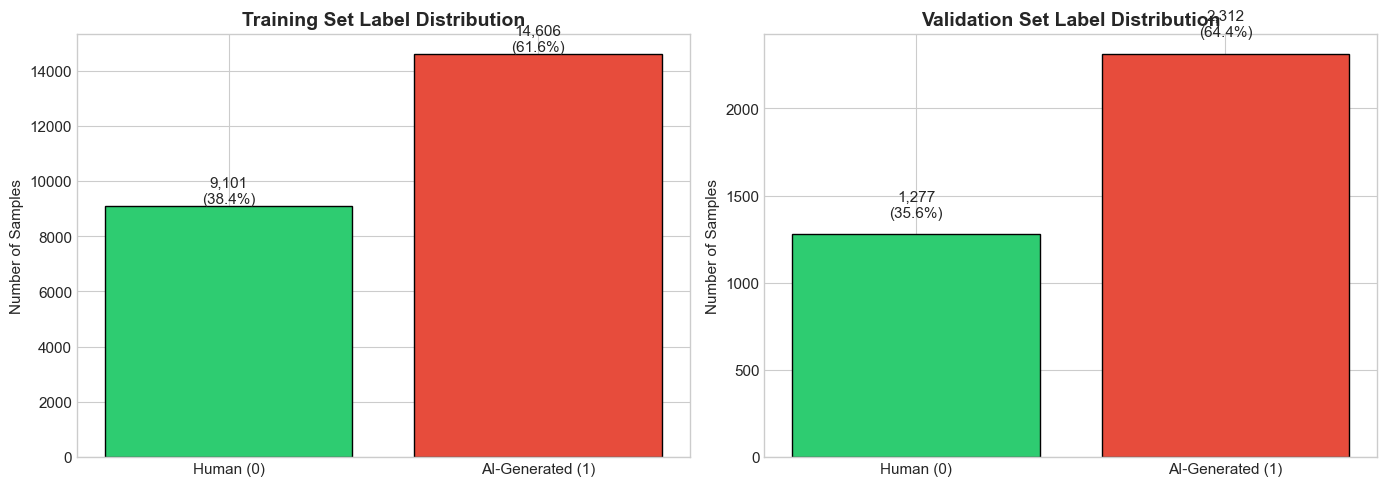

Label Distribution Summary:
  Training: {1: 14606, 0: 9101}
  Validation: {1: 2312, 0: 1277}


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, df) in zip(axes, [('Training', train_df), ('Validation', val_df)]):
    counts = df['label'].value_counts().sort_index()
    colors = ['#2ecc71', '#e74c3c']  # Green for human, red for AI
    bars = ax.bar(['Human (0)', 'AI-Generated (1)'], counts.values, color=colors, edgecolor='black')
    ax.set_title(f'{name} Set Label Distribution', fontsize=14, fontweight='bold')
    ax.set_ylabel('Number of Samples')
    
    # Add percentage labels
    total = counts.sum()
    for bar, count in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
                f'{count:,}\n({count/total*100:.1f}%)', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

# Print exact numbers
print("Label Distribution Summary:")
print(f"  Training: {train_df['label'].value_counts().to_dict()}")
print(f"  Validation: {val_df['label'].value_counts().to_dict()}")

### Label Balance

The dataset has a specific human-to-AI ratio. This imbalance necessitates metrics robust to class distribution (like ROC-AUC) or careful calibration. Sampling strategies may be required if the imbalance is severe.

## 3. Text & Token Analysis

We analyze physical length (words/chars) and semantic density (tokens). Differences here can reveal biases or shortcuts models might exploit.

In [33]:
# Load tokenizer
try:
    # Using DeBERTa tokenizer as used in training
    tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-v3-base")
except:
    tokenizer = AutoTokenizer.from_pretrained("roberta-base")

def calc_stats(df):
    df['char_length'] = df['text'].str.len()
    df['word_count'] = df['text'].str.split().str.len()
    # Tokenize (using batch encoding for speed if dataset grows, apply is consistent for exploration)
    df['token_count'] = df['text'].apply(lambda x: len(tokenizer.encode(x, add_special_tokens=False)))
    df['mean_word_length'] = df['text'].map(lambda x: np.mean([len(word) for word in x.split()]))
    df['mean_sent_length'] = df['text'].map(lambda x: np.mean([len(sent) for sent in tokenize.sent_tokenize(x)]))
    return df

print("Processing Train...")
train_df = calc_stats(train_df)
print("Processing Val...")
val_df = calc_stats(val_df)

# Stats
print("=" * 40)
for label, name in [(0, 'Human'), (1, 'AI-Generated')]:
    subset = train_df[train_df['label'] == label]
    print(f"\n{name} Texts (Train):")
    print(f"  Words:  median={subset['word_count'].median():.0f}, mean={subset['word_count'].mean():.0f}")
    print(f"  Tokens: median={subset['token_count'].median():.0f}, mean={subset['token_count'].mean():.0f}")

Could not extract SentencePiece model from /Users/tanish/.cache/huggingface/hub/models--microsoft--deberta-v3-base/snapshots/8ccc9b6f36199bec6961081d44eb72fb3f7353f3/spm.model using sentencepiece library due to 
SentencePieceExtractor requires the protobuf library but it was not found in your environment. Check out the instructions on the
installation page of its repo: https://github.com/protocolbuffers/protobuf/tree/master/python#installation and follow the ones
that match your environment. Please note that you may need to restart your runtime after installation.
. Falling back to TikToken extractor.


Processing Train...


Token indices sequence length is longer than the specified maximum sequence length for this model (593 > 512). Running this sequence through the model will result in indexing errors


Processing Val...

Human Texts (Train):
  Words:  median=670, mean=695
  Tokens: median=921, mean=941

AI-Generated Texts (Train):
  Words:  median=546, mean=575
  Tokens: median=710, mean=759


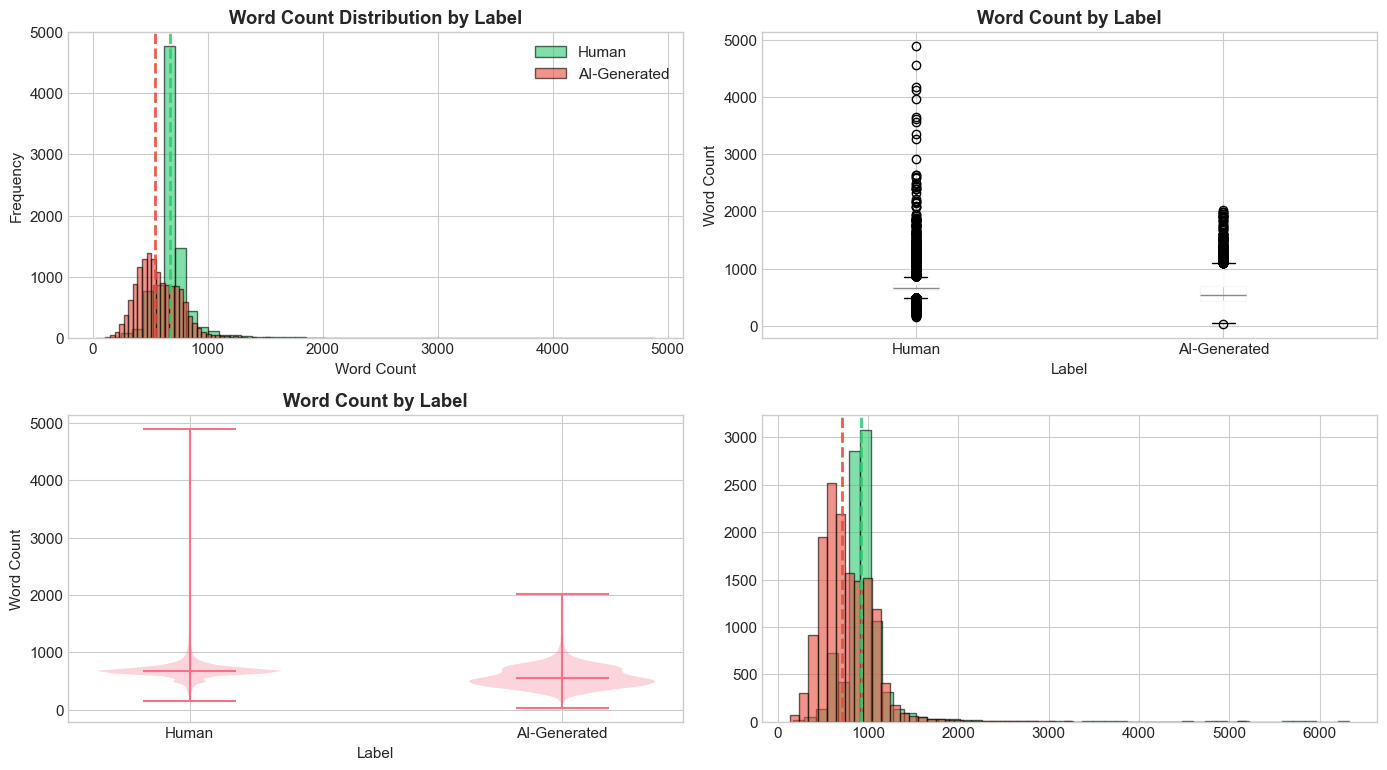

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Flatten for easier indexing
axes = axes.flatten()

# ---- Histogram (top-left) ----
for label, color, name in [
    (0, '#2ecc71', 'Human'),
    (1, '#e74c3c', 'AI-Generated')
]:
    subset = train_df[train_df['label'] == label]
    axes[0].hist(
        subset['word_count'],
        bins=50,
        alpha=0.6,
        label=name,
        color=color,
        edgecolor='black'
    )

    median = subset['word_count'].median()
    axes[0].axvline(
        median,
        color=color,
        linestyle='--',
        linewidth=2,
        alpha=0.9
    )

axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Word Count Distribution by Label', fontweight='bold')
axes[0].legend()

# ---- Box plot (top-right) ----
train_df.boxplot(column='word_count', by='label', ax=axes[1])
axes[1].set_xticklabels(['Human', 'AI-Generated'])
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Word Count')
axes[1].set_title('Word Count by Label', fontweight='bold')
plt.suptitle('')

# ---- Violin plot (bottom-left) ----
data = [
    train_df[train_df['label'] == 0]['word_count'],
    train_df[train_df['label'] == 1]['word_count']
]

axes[2].violinplot(
    data,
    showmeans=False,
    showmedians=True,
    showextrema=True
)

axes[2].set_xticks([1, 2])
axes[2].set_xticklabels(['Human', 'AI-Generated'])
axes[2].set_xlabel('Label')
axes[2].set_ylabel('Word Count')
axes[2].set_title('Word Count by Label', fontweight='bold')

# ---- Histogram (bottom-right) ----
for label, color, name in [
    (0, '#2ecc71', 'Human'),
    (1, '#e74c3c', 'AI-Generated')
]:
    subset = train_df[train_df['label'] == label]
    axes[3].hist(
        subset['token_count'],
        bins=50,
        alpha=0.6,
        label=name,
        color=color,
        edgecolor='black'
    )

    median = subset['token_count'].median()
    axes[3].axvline(
        median,
        color=color,
        linestyle='--',
        linewidth=2,
        alpha=0.9
    )

plt.tight_layout()
plt.show()

In [50]:
train_df['tag'] = train_df['label'].map({0: 'human', 1: 'ai'})

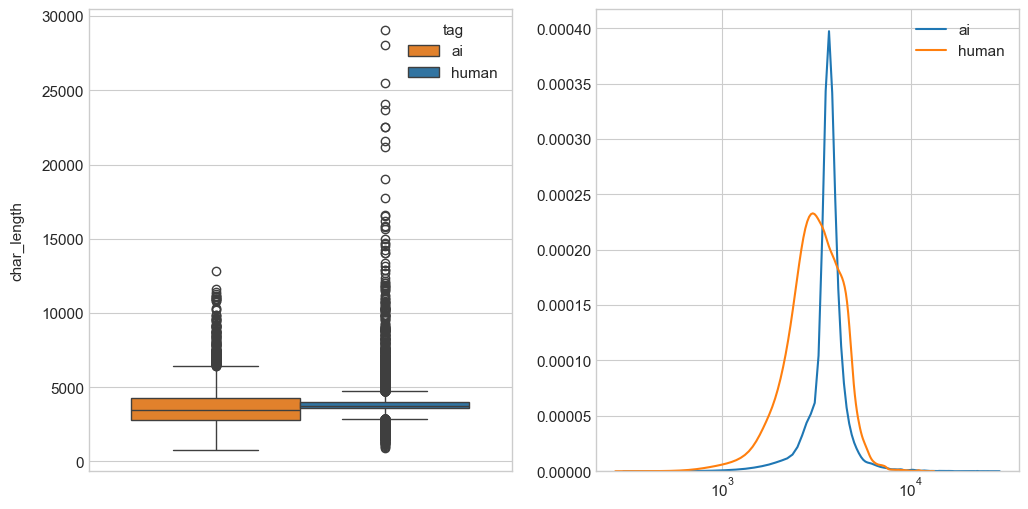

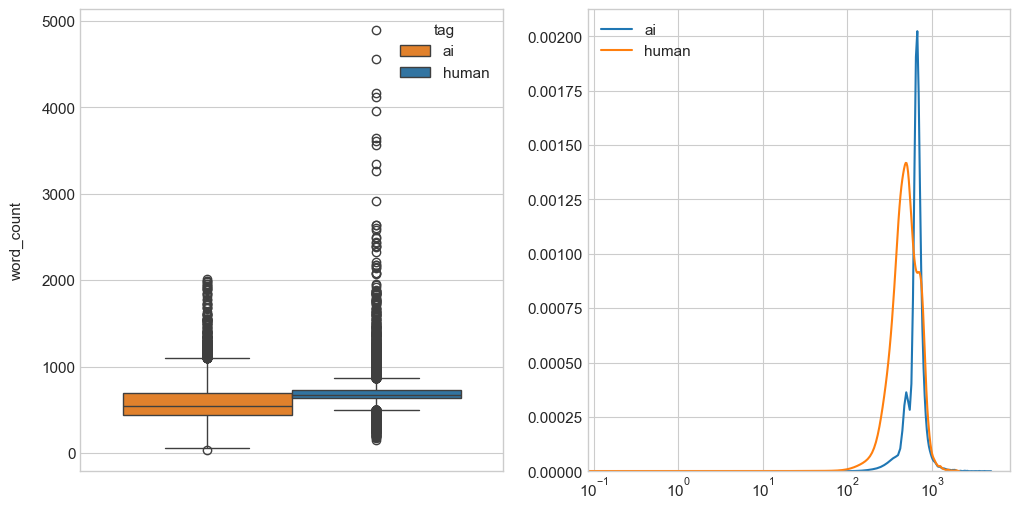

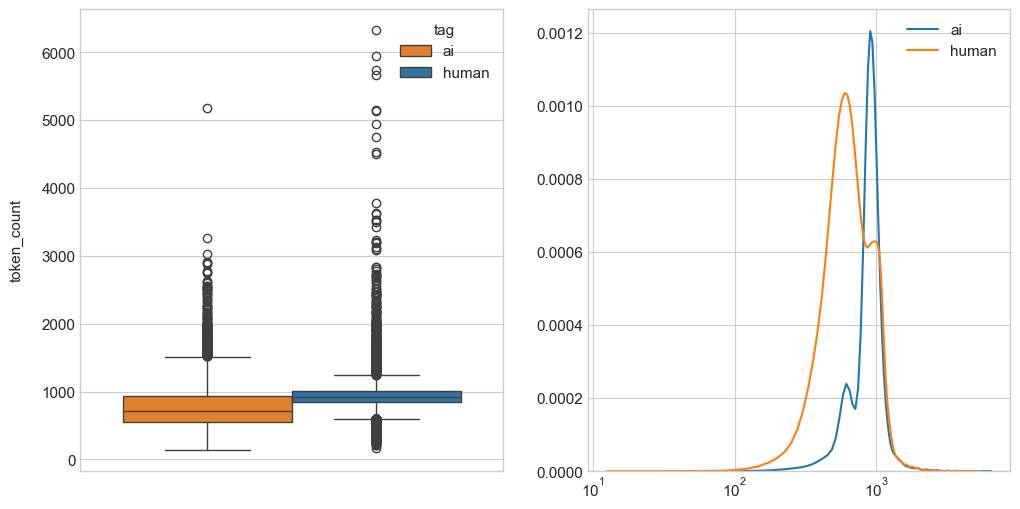

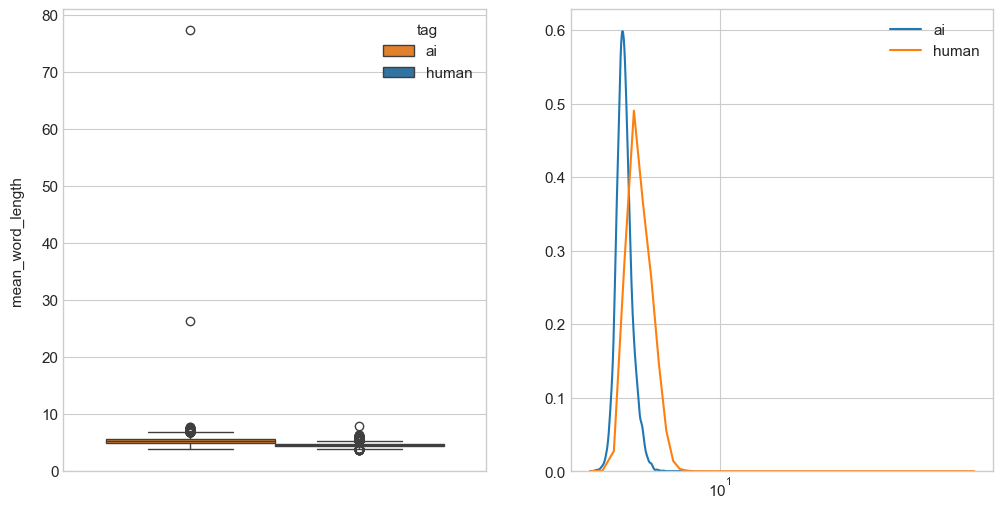

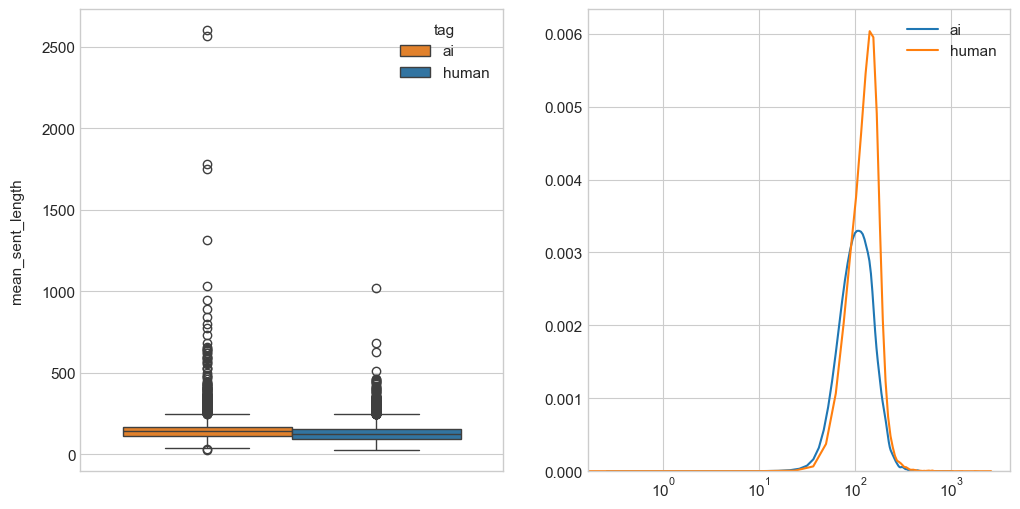

In [56]:
def visualize(col):

    palette = {
        'human': 'tab:blue',
        'ai': 'tab:orange'
    }
    
    print()
    plt.subplot(1,2,1)
    sns.boxplot(y=train_df[col], hue=train_df['tag'], palette=palette)
    plt.ylabel(col, labelpad=12.5)
    
    plt.subplot(1,2,2)
    sns.kdeplot(x=train_df[col], hue=train_df['tag'], palette=palette)
    plt.legend(train_df['tag'].unique())
    plt.xlabel('')
    plt.ylabel('')

    plt.xscale('log')
    
    plt.show()

features = train_df.columns.tolist()[5:-1]
for feature in features:
    visualize(feature)

### Token Distribution & Divergence

We analyze the distribution of token frequencies (Zipf's law) and the semantic divergence between classes.

Aggregating token counts...


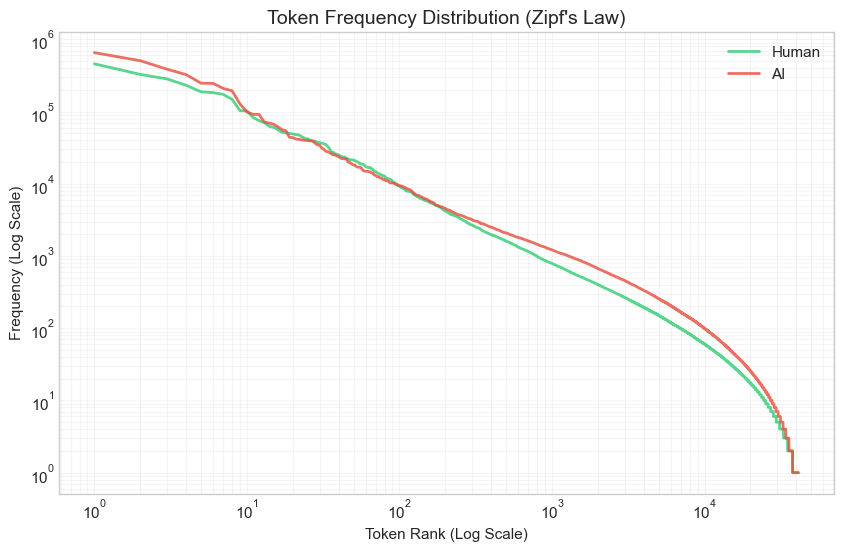


Jensen-Shannon Divergence: 0.2432

Most distinctive tokens (by raw probability difference):
  'of': Human=0.0214, AI=0.0293, Diff=0.0079
  'the': Human=0.0382, AI=0.0457, Diff=0.0075
  '�': Human=0.0119, AI=0.0051, Diff=0.0068
  ',': Human=0.0536, AI=0.0592, Diff=0.0056
  'a': Human=0.0172, AI=0.0223, Diff=0.0051
  '': Human=0.0270, AI=0.0222, Diff=0.0048
  'was': Human=0.0097, AI=0.0049, Diff=0.0048
  'I': Human=0.0082, AI=0.0038, Diff=0.0045
  ';': Human=0.0049, AI=0.0007, Diff=0.0043
  'he': Human=0.0073, AI=0.0037, Diff=0.0036


In [57]:
def get_token_frequencies(texts):
    counter = Counter()
    for text in texts:
        # Use tokenizer from previous cell
        tokens = tokenizer.encode(text, add_special_tokens=False)
        counter.update(tokens)
    return counter

print("Aggregating token counts...")
human_tokens = get_token_frequencies(train_df[train_df['label'] == 0]['text'])
ai_tokens = get_token_frequencies(train_df[train_df['label'] == 1]['text'])

# --- Plot 1: Log-Log Zipf Plot ---
def get_ranks(counter):
    freqs = np.sort(list(counter.values()))[::-1]
    ranks = np.arange(1, len(freqs) + 1)
    return ranks, freqs

h_ranks, h_freqs = get_ranks(human_tokens)
a_ranks, a_freqs = get_ranks(ai_tokens)

plt.figure(figsize=(10, 6))
plt.loglog(h_ranks, h_freqs, label='Human', color='#2ecc71', alpha=0.8, linewidth=2)
plt.loglog(a_ranks, a_freqs, label='AI', color='#e74c3c', alpha=0.8, linewidth=2)
plt.xlabel('Token Rank (Log Scale)')
plt.ylabel('Frequency (Log Scale)')
plt.title('Token Frequency Distribution (Zipf\'s Law)', fontsize=14)
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

# --- Analysis 2: Distribution Divergence ---
# Normalize distributions over the union vocabulary
all_vocab = list(set(human_tokens.keys()) | set(ai_tokens.keys()))
vocab_idx = {t: i for i, t in enumerate(all_vocab)}
size = len(all_vocab)

p = np.zeros(size)
q = np.zeros(size)

total_h = sum(human_tokens.values())
total_a = sum(ai_tokens.values())

for t, c in human_tokens.items():
    p[vocab_idx[t]] = c / total_h

for t, c in ai_tokens.items():
    q[vocab_idx[t]] = c / total_a

# Smoothing for stability
p += 1e-12; p /= p.sum()
q += 1e-12; q /= q.sum()

js_div = jensenshannon(p, q)
print(f"\nJensen-Shannon Divergence: {js_div:.4f}")

# Identify top distinctive tokens
print("\nMost distinctive tokens (by raw probability difference):")
diffs = np.abs(p - q)
top_indices = diffs.argsort()[-10:][::-1]

for idx in top_indices:
    token_id = all_vocab[idx]
    token_str = tokenizer.decode([token_id]).strip()
    print(f"  '{token_str}': Human={p[idx]:.4f}, AI={q[idx]:.4f}, Diff={diffs[idx]:.4f}")

---
## 4. N-Gram Analysis

Analyzing n-grams (sequences of n words) helps capture context and common phrases that single words miss. We examine the most frequent bigrams (2 words) and trigrams (3 words) to see if AI models rely on specific catchphrases or structural patterns.

Analyzing Bigrams (2-grams)...


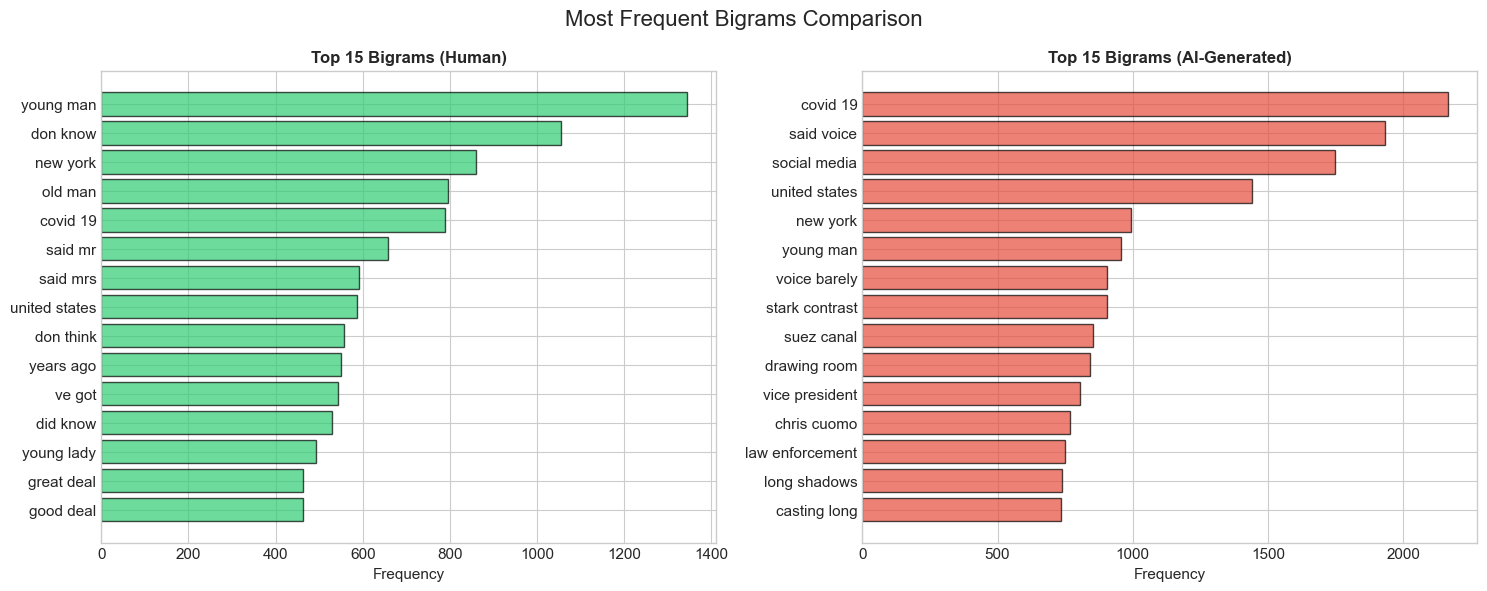

Analyzing Trigrams (3-grams)...


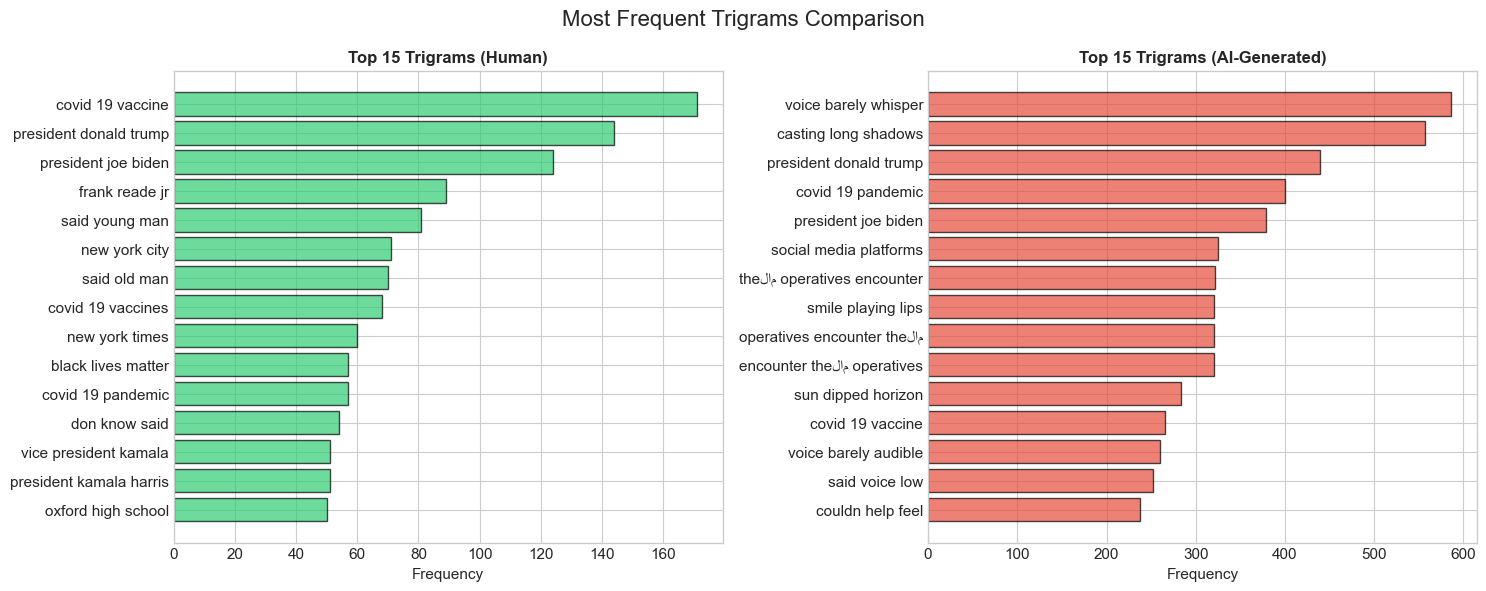

In [59]:
from sklearn.feature_extraction.text import CountVectorizer

def plot_top_ngrams(df, n=2, top_k=15, title=''):
    # We use a simple CountVectorizer; for large datasets, consider limiting max_features
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english', max_features=10000)
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    for idx, (label, name, color) in enumerate([(0, 'Human', '#2ecc71'), (1, 'AI-Generated', '#e74c3c')]):
        subset = df[df['label'] == label]['text']
        X = vec.fit_transform(subset)
        sum_words = X.sum(axis=0)
        words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
        words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_k]
        
        # Unzip for plotting
        if not words_freq:
            continue
        words, freqs = zip(*words_freq)
        
        axes[idx].barh(words, freqs, color=color, edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'Top {top_k} {title} ({name})', fontsize=12, fontweight='bold')
        axes[idx].invert_yaxis()  # Best on top
        axes[idx].set_xlabel('Frequency')

    plt.suptitle(f'Most Frequent {title} Comparison', fontsize=16)
    plt.tight_layout()
    plt.show()

print("Analyzing Bigrams (2-grams)...")
plot_top_ngrams(train_df, n=2, title='Bigrams')

print("Analyzing Trigrams (3-grams)...")
plot_top_ngrams(train_df, n=3, title='Trigrams')

### 📊 Insight: Phrase Patterns

- **Repetitive Phrases:** AI models often overuse specific connective phrases (e.g., "In conclusion," "It is important to note") or hedging language.
- **Topic Divergence:** Are Human texts focusing on different topics/entities compared to AI?
- **Action:** If distinct N-gram artifacts are found, they can be powerful features for the classifier.

### Length & Token Patterns

- **Lengths**: Significant differences in length distributions can suggest model biases.
- **Tokens**: Divergence in token distributions (Zipf plots) indicates vocabulary/grammar variance. High JS divergence suggests the two classes are linguistically distinct, potentially making detection easier.

---
## 5. Model (Generator) Analysis

Understanding which AI models generated the training data is crucial for:
1. Ensuring diverse representation of AI writing styles
2. Identifying potential gaps (missing generator families)
3. Understanding what "AI-generated" means in this context

In [8]:
# Model distribution
model_counts = train_df['model'].value_counts()
print(f"Unique generators in training data: {len(model_counts)}")
print("\nGenerator Distribution:")
print(model_counts.to_string())

Unique generators in training data: 23

Generator Distribution:
model
human                           9101
gpt-3.5-turbo                   1374
gpt-4o-mini                     1358
gpt-4o                          1336
ministral-8b-instruct-2410      1100
gemini-2.0-flash                1079
o3-mini                         1075
gemini-1.5-pro                  1072
llama-3.1-8b-instruct           1063
deepseek-r1-distill-qwen-32b     901
falcon3-10b-instruct             879
llama-3.3-70b-instruct           405
gpt-4.5-preview                  278
gpt-4-turbo-paraphrase           276
gemini-pro                       276
gpt-4-turbo                      272
qwen1.5-72b-chat-8bit            271
llama-2-70b-chat                 269
mistral-7b-instruct-v0.2         266
gemini-pro-paraphrase            265
text-bison-002                   265
mixtral-8x7b-instruct-v0.1       264
llama-2-7b-chat                  262


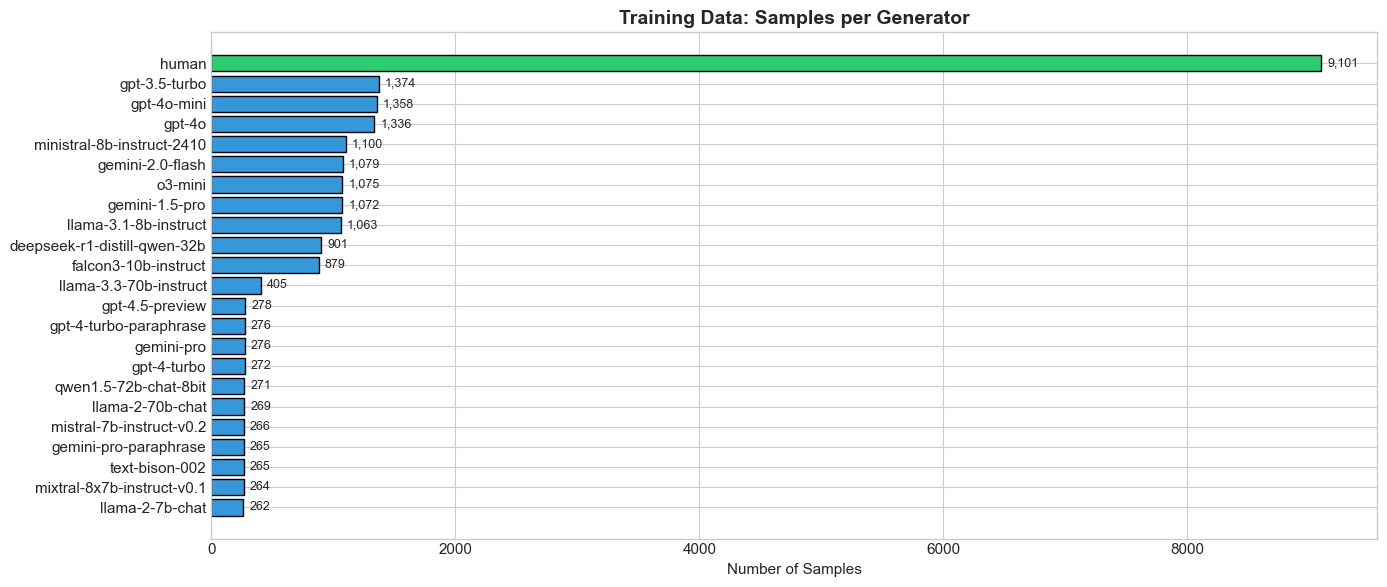

In [9]:
# Visualize model distribution
fig, ax = plt.subplots(figsize=(14, 6))

colors = ['#2ecc71' if m == 'human' else '#3498db' for m in model_counts.index]
bars = ax.barh(model_counts.index, model_counts.values, color=colors, edgecolor='black')
ax.set_xlabel('Number of Samples')
ax.set_title('Training Data: Samples per Generator', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add count labels
for bar, count in zip(bars, model_counts.values):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2, 
            f'{count:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [10]:
# Categorize generators by family
def categorize_model(model_name):
    model_lower = model_name.lower()
    if model_lower == 'human':
        return 'Human'
    elif 'gpt' in model_lower or 'openai' in model_lower:
        return 'OpenAI (GPT)'
    elif 'claude' in model_lower:
        return 'Anthropic (Claude)'
    elif 'gemini' in model_lower or 'google' in model_lower:
        return 'Google (Gemini)'
    elif 'llama' in model_lower or 'meta' in model_lower:
        return 'Meta (Llama)'
    elif 'deepseek' in model_lower:
        return 'DeepSeek'
    elif 'mistral' in model_lower:
        return 'Mistral'
    elif 'qwen' in model_lower:
        return 'Alibaba (Qwen)'
    else:
        return 'Other'

train_df['model_family'] = train_df['model'].apply(categorize_model)

family_counts = train_df['model_family'].value_counts()
print("Generator Family Distribution:")
print(family_counts.to_string())

Generator Family Distribution:
model_family
Human              9101
OpenAI (GPT)       4894
Other              3583
Google (Gemini)    2692
Meta (Llama)       1999
DeepSeek            901
Alibaba (Qwen)      271
Mistral             266


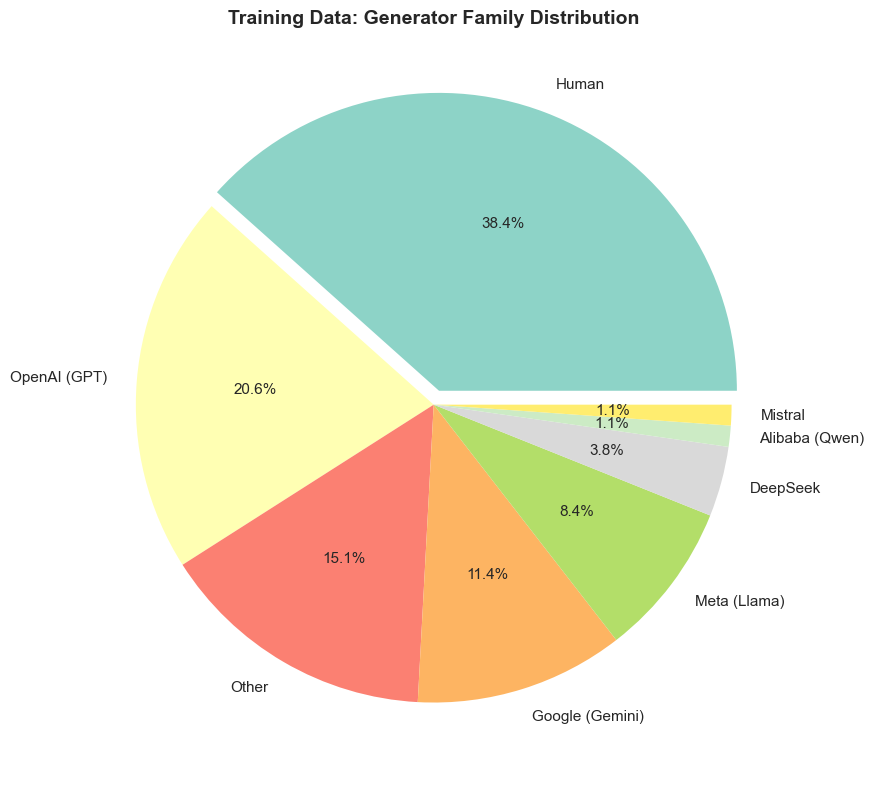

In [11]:
# Pie chart of model families
fig, ax = plt.subplots(figsize=(10, 8))

colors = plt.cm.Set3(np.linspace(0, 1, len(family_counts)))
wedges, texts, autotexts = ax.pie(family_counts.values, labels=family_counts.index, 
                                   autopct='%1.1f%%', colors=colors, 
                                   explode=[0.05 if f == 'Human' else 0 for f in family_counts.index])
ax.set_title('Training Data: Generator Family Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 6. Genre Analysis

Understanding genre distribution helps us:
1. Know what types of text we're classifying
2. Identify potential domain shift issues
3. Design experiments that test across genres

In [12]:
print("Genre Distribution (Training):")
genre_counts = train_df['genre'].value_counts()
print(genre_counts.to_string())

print(f"\nUnique genres: {train_df['genre'].nunique()}")

Genre Distribution (Training):
genre
fiction    14697
essays      4661
news        4349

Unique genres: 3


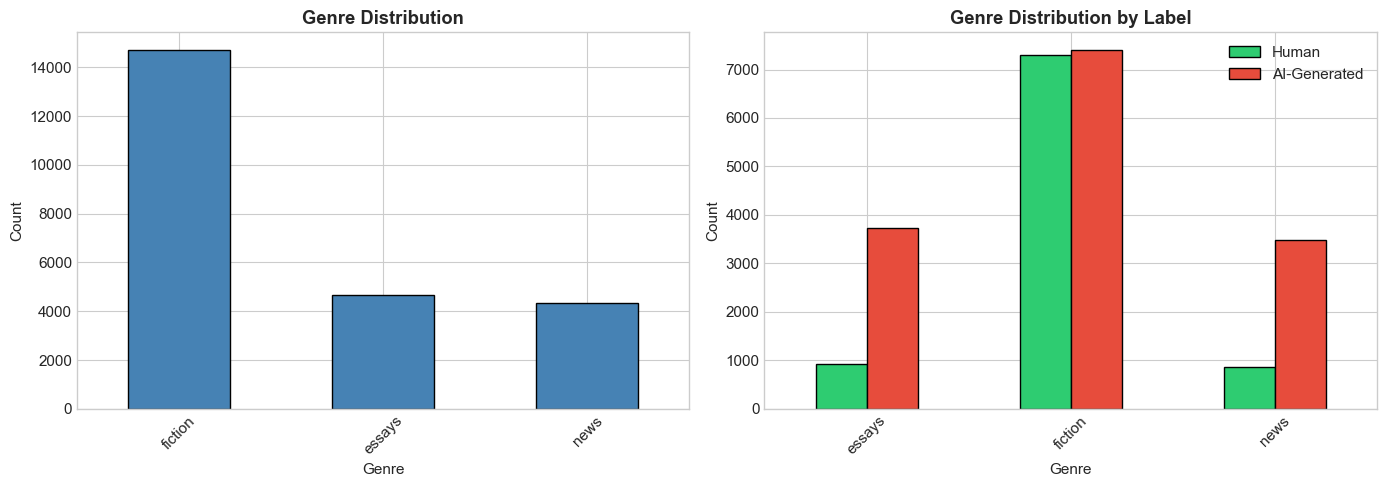

In [13]:
# Genre distribution visualization
if train_df['genre'].nunique() > 1:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Overall genre distribution
    genre_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
    axes[0].set_title('Genre Distribution', fontweight='bold')
    axes[0].set_xlabel('Genre')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Genre × Label distribution
    genre_label = train_df.groupby(['genre', 'label']).size().unstack(fill_value=0)
    genre_label.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'], edgecolor='black')
    axes[1].set_title('Genre Distribution by Label', fontweight='bold')
    axes[1].set_xlabel('Genre')
    axes[1].set_ylabel('Count')
    axes[1].legend(['Human', 'AI-Generated'])
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Dataset contains only one genre: {train_df['genre'].iloc[0]}")

---
## 7. Linguistic Feature Analysis

These features capture writing style characteristics that may differ between human and AI text.

In [14]:
def compute_linguistic_features(text):
    """Compute various linguistic features for a text."""
    words = text.split()
    sentences = re.split(r'[.!?]+', text)
    sentences = [s.strip() for s in sentences if s.strip()]
    
    # Basic counts
    word_count = len(words)
    sentence_count = len(sentences) if sentences else 1
    
    # Average word length
    avg_word_length = np.mean([len(w) for w in words]) if words else 0
    
    # Average sentence length
    avg_sentence_length = word_count / sentence_count
    
    # Vocabulary richness (type-token ratio)
    unique_words = set(w.lower() for w in words)
    ttr = len(unique_words) / word_count if word_count > 0 else 0
    
    # Punctuation density
    punct_count = sum(1 for c in text if c in '.,!?;:"\'()-')
    punct_density = punct_count / len(text) if text else 0
    
    # Question/exclamation ratio
    question_count = text.count('?')
    exclamation_count = text.count('!')
    
    # Paragraph count (approximated by double newlines)
    para_count = len(re.split(r'\n\n+', text))
    
    return {
        'avg_word_length': avg_word_length,
        'avg_sentence_length': avg_sentence_length,
        'type_token_ratio': ttr,
        'punct_density': punct_density,
        'question_count': question_count,
        'exclamation_count': exclamation_count,
        'para_count': para_count
    }

# Compute features for a sample (full computation is slow)
print("Computing linguistic features (sampling 5000 texts for speed)...")
sample_df = train_df.sample(min(5000, len(train_df)), random_state=42).copy()

features_list = sample_df['text'].apply(compute_linguistic_features)
features_df = pd.DataFrame(features_list.tolist())
sample_df = pd.concat([sample_df.reset_index(drop=True), features_df], axis=1)

print("Done!")

Computing linguistic features (sampling 5000 texts for speed)...
Done!


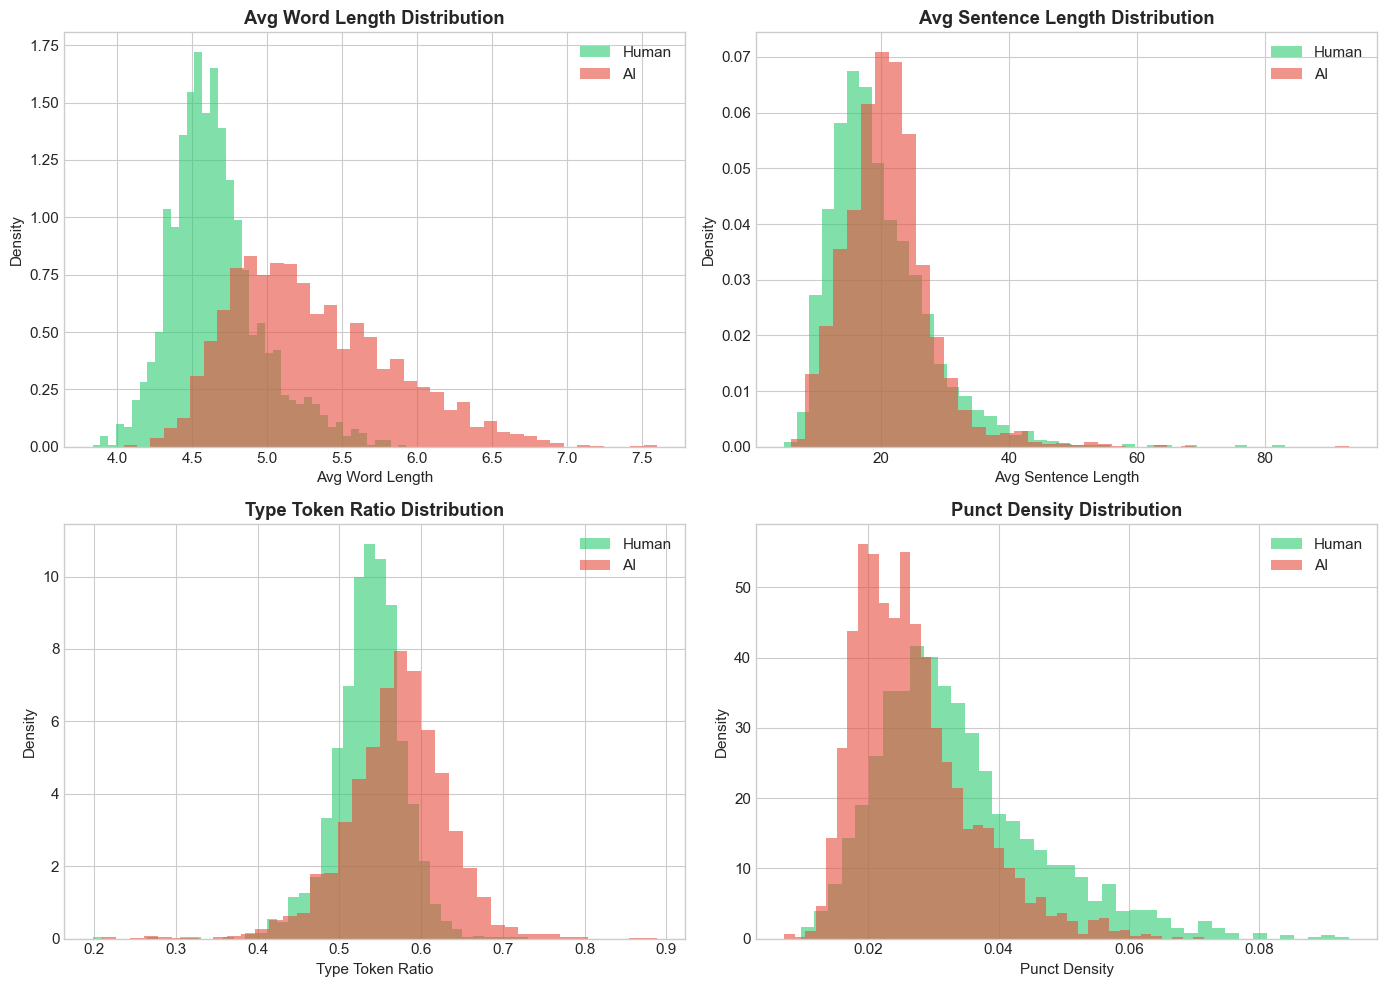

In [15]:
# Compare features by label
feature_cols = ['avg_word_length', 'avg_sentence_length', 'type_token_ratio', 'punct_density']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, feature_cols):
    for label, color, name in [(0, '#2ecc71', 'Human'), (1, '#e74c3c', 'AI')]:
        subset = sample_df[sample_df['label'] == label][col]
        ax.hist(subset, bins=40, alpha=0.6, label=name, color=color, density=True)
    ax.set_xlabel(col.replace('_', ' ').title())
    ax.set_ylabel('Density')
    ax.set_title(f'{col.replace("_", " ").title()} Distribution', fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.show()

In [16]:
# Statistical comparison
print("=" * 70)
print("LINGUISTIC FEATURE COMPARISON (Human vs AI)")
print("=" * 70)

for col in feature_cols:
    human_mean = sample_df[sample_df['label'] == 0][col].mean()
    ai_mean = sample_df[sample_df['label'] == 1][col].mean()
    diff_pct = ((ai_mean - human_mean) / human_mean) * 100 if human_mean != 0 else 0
    
    print(f"\n{col.replace('_', ' ').title()}:")
    print(f"  Human: {human_mean:.4f}")
    print(f"  AI:    {ai_mean:.4f}")
    print(f"  Diff:  {diff_pct:+.1f}%")

LINGUISTIC FEATURE COMPARISON (Human vs AI)

Avg Word Length:
  Human: 4.6510
  AI:    5.2949
  Diff:  +13.8%

Avg Sentence Length:
  Human: 19.8816
  AI:    21.1111
  Diff:  +6.2%

Type Token Ratio:
  Human: 0.5360
  AI:    0.5704
  Diff:  +6.4%

Punct Density:
  Human: 0.0339
  AI:    0.0269
  Diff:  -20.6%


### 📊 Insight: Linguistic Patterns

**Key findings to look for:**

1. **Type-Token Ratio (Vocabulary Diversity):**
   - If AI has lower TTR: AI may be more repetitive, using a narrower vocabulary
   - This is a known characteristic of many language models

2. **Sentence Length:**
   - AI models often produce more uniform sentence lengths
   - Humans have higher variance ("burstiness")

3. **Punctuation Patterns:**
   - AI may overuse certain punctuation (e.g., colons, em-dashes)
   - Human text often has more varied punctuation usage

**Implications for experiments:**
1. **Stylometric features can help** but may also overfit to specific generators
2. **These patterns may not hold for all AI models** - test generalization carefully
3. **Consider robustness:** Can adversaries easily modify punctuation/sentence length to evade detection?

---
## 8. Cross-Feature Analysis

In [17]:
# Text length by model
model_length_stats = train_df.groupby('model')['word_count'].agg(['mean', 'median', 'std']).round(1)
model_length_stats = model_length_stats.sort_values('mean', ascending=False)
print("Average Word Count by Model:")
print(model_length_stats.to_string())

Average Word Count by Model:
                               mean  median    std
model                                             
deepseek-r1-distill-qwen-32b  849.8   818.0  336.0
llama-3.3-70b-instruct        745.6   782.0  174.6
human                         695.5   670.0  209.8
o3-mini                       679.1   686.0  196.3
gpt-4o-mini                   621.5   659.0  156.6
ministral-8b-instruct-2410    620.2   652.0  180.6
gpt-4.5-preview               603.0   569.5  170.3
gemini-2.0-flash              595.1   603.0  110.1
gpt-4o                        590.5   590.0  152.7
llama-3.1-8b-instruct         572.6   554.0  160.3
falcon3-10b-instruct          565.9   561.0  145.5
mixtral-8x7b-instruct-v0.1    530.6   518.0  131.1
mistral-7b-instruct-v0.2      530.3   501.5  130.5
text-bison-002                518.7   501.0  120.3
gpt-4-turbo                   517.2   497.0  129.0
gemini-1.5-pro                506.3   504.0  132.4
llama-2-70b-chat              501.2   492.0  107.1
ge

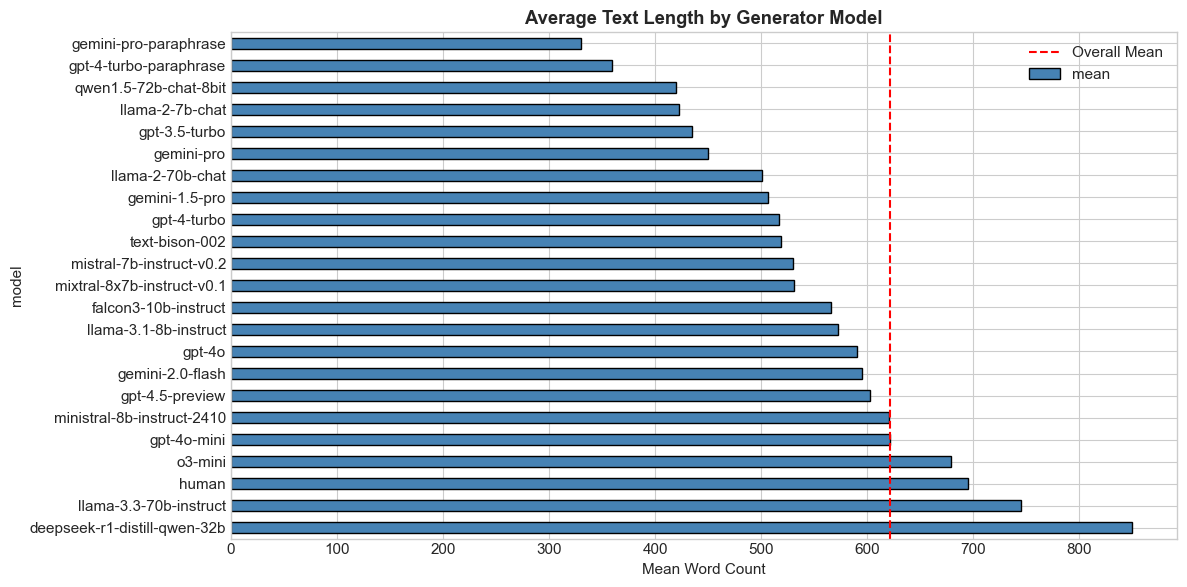

In [18]:
# Heatmap of word count by model
fig, ax = plt.subplots(figsize=(12, 6))

model_length_stats['mean'].plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.axvline(train_df['word_count'].mean(), color='red', linestyle='--', label='Overall Mean')
ax.set_xlabel('Mean Word Count')
ax.set_title('Average Text Length by Generator Model', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

---
## 9. External (OOD) Datasets Analysis

Understanding the external datasets is crucial because **OOD generalization is the main challenge** in this task.

In [19]:
# Load and analyze external datasets
external_files = [f.name for f in EXTERNAL_DIR.iterdir() if f.suffix == '.jsonl']
print(f"External datasets found: {external_files}")

external_dfs = {}
for fname in external_files:
    path = EXTERNAL_DIR / fname
    df = load_jsonl(path)
    name = fname.replace('.jsonl', '')
    external_dfs[name] = df
    print(f"\n{name}: {len(df):,} samples")
    print(f"  Columns: {df.columns.tolist()}")
    if 'label' in df.columns:
        print(f"  Labels: {df['label'].value_counts().to_dict()}")

External datasets found: ['ghostbuster.jsonl', 'raid.jsonl', 'turingbench.jsonl', 'm4.jsonl', 'hc3_wiki_processed.jsonl', 'hc3_wiki_raw.jsonl']

ghostbuster: 500 samples
  Columns: ['text', 'label', 'source']
  Labels: {1: 257, 0: 243}

raid: 500 samples
  Columns: ['text', 'label', 'source']
  Labels: {0: 253, 1: 247}

turingbench: 500 samples
  Columns: ['text', 'label', 'source']
  Labels: {0: 253, 1: 247}

m4: 500 samples
  Columns: ['text', 'label', 'source']
  Labels: {0: 255, 1: 245}

hc3_wiki_processed: 1,684 samples
  Columns: ['text', 'label', 'source']
  Labels: {1: 842, 0: 842}

hc3_wiki_raw: 842 samples
  Columns: ['question', 'human_answers', 'chatgpt_answers']


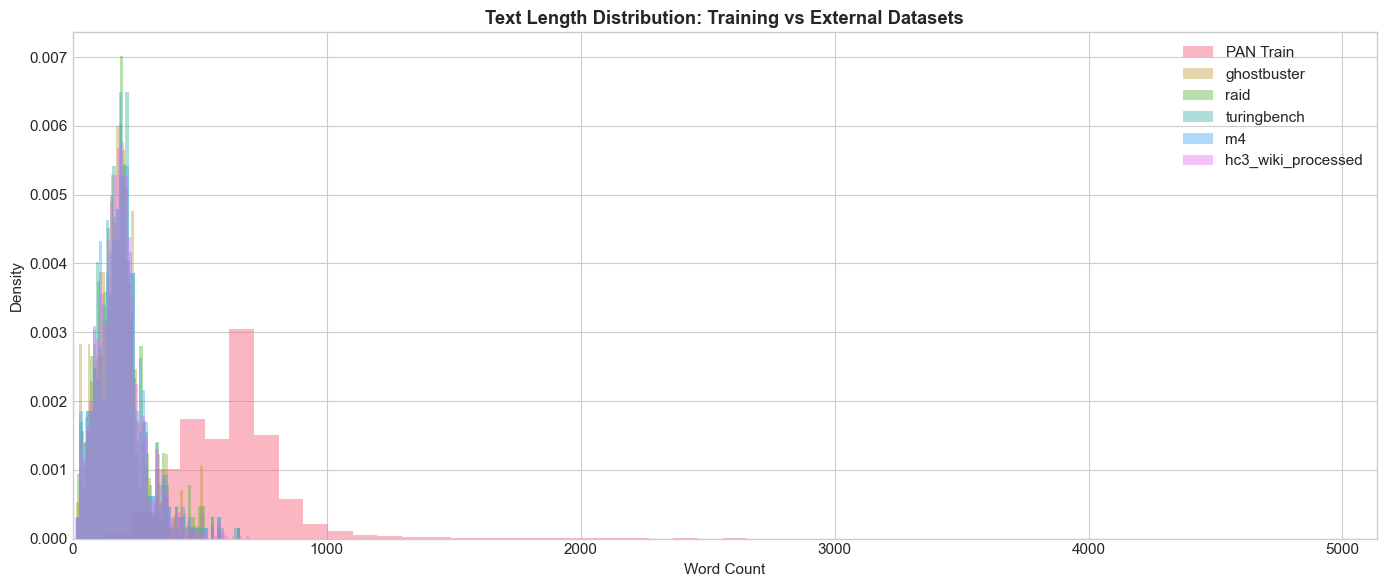

In [20]:
# Compare text length distributions across datasets
fig, ax = plt.subplots(figsize=(14, 6))

# Add training data
train_df['word_count'].hist(ax=ax, bins=50, alpha=0.5, label='PAN Train', density=True)

# Add external datasets
for name, df in external_dfs.items():
    if 'text' in df.columns:
        word_counts = df['text'].str.split().str.len()
        word_counts.hist(ax=ax, bins=50, alpha=0.4, label=name, density=True)

ax.set_xlabel('Word Count')
ax.set_ylabel('Density')
ax.set_title('Text Length Distribution: Training vs External Datasets', fontweight='bold')
ax.legend()
ax.set_xlim(0, ax.get_xlim()[1])  # Start from 0

plt.tight_layout()
plt.show()

In [21]:
# Analyze source/model distribution in external datasets
print("=" * 60)
print("EXTERNAL DATASET SOURCES/MODELS")
print("=" * 60)

for name, df in external_dfs.items():
    print(f"\n{name.upper()}:")
    if 'source' in df.columns:
        print(f"  Sources: {df['source'].value_counts().to_dict()}")
    if 'model' in df.columns:
        print(f"  Models: {df['model'].value_counts().head(5).to_dict()}")
    
    # Sample text preview
    if 'text' in df.columns:
        sample_text = df['text'].iloc[0][:200]
        print(f"  Sample: {sample_text}...")

EXTERNAL DATASET SOURCES/MODELS

GHOSTBUSTER:
  Sources: {'ghostbuster': 500}
  Sample: Linear network coding is a method of transmitting data across a network in which the intermediate nodes in the network are permitted to perform coding operations on the data they receive, rather than ...

RAID:
  Sources: {'raid': 500}
  Sample: An array is a data structure that stores a collection of items, typically in a contiguous block of memory. The items in an array are usually of the same data type, and are accessed using an index.



...

TURINGBENCH:
  Sources: {'turingbench': 500}
  Sample: An epigenetic clock is a biochemical test that can be used to measure age. The test is based on DNA methylation levels, measuring the accumulation of methyl groups to one's DNA molecules....

M4:
  Sources: {'m4': 500}
  Sample: Computational statistics is a field of study that combines statistical methods with computational techniques to analyze and solve problems in statistical data analysis. It invol

---
## 9. Key Insights Summary

### Dataset Characteristics

| Aspect | Finding | Implication |
|--------|---------|-------------|
| **Size** | ~24K train, ~3.5K val | Sufficient for fine-tuning transformers |
| **Balance** | Check pie chart above | May need stratified sampling if imbalanced |
| **Generators** | Multiple AI families represented | Good for diversity, but OOD generators will differ |
| **Genres** | Primarily essays | May not generalize to other text types |
| **Text Length** | Variable, some very long | Need chunking strategy for transformers |

### Critical Challenges

1. **OOD Generalization is the bottleneck**
   - Models easily achieve >99% on validation
   - But drop to ~55% on external data (near random)
   - This suggests models are learning dataset-specific patterns, not general AI signatures

2. **Spurious Correlations Risk**
   - Text length, specific punctuation patterns, model-specific vocabulary
   - These "shortcuts" work in-distribution but fail OOD

3. **Evolving AI Landscape**
   - New models constantly released
   - Detection methods must be forward-compatible

### Recommendations for Future Experiments

1. **Evaluation Strategy**
   - Always report OOD performance alongside validation scores
   - Use cross-generator validation (hold out model families)
   - Test on multiple external datasets

2. **Feature Engineering**
   - Focus on fundamental linguistic patterns (burstiness, perplexity)
   - Avoid features tied to specific generators
   - Consider length-normalized features

3. **Model Architecture**
   - Transformers (DeBERTa) show modest OOD improvement over baselines
   - Consider perplexity-based approaches using language models
   - Explore contrastive learning for domain invariance

4. **Data Augmentation**
   - Generate adversarial examples (paraphrased AI text)
   - Include more diverse AI generators in training
   - Consider domain randomization techniques

In [22]:
# Final summary statistics
print("=" * 70)
print("FINAL SUMMARY: PAN 2025 DATASET")
print("=" * 70)
print(f"\nTraining Set:")
print(f"  Total samples: {len(train_df):,}")
print(f"  Human samples: {(train_df['label'] == 0).sum():,} ({(train_df['label'] == 0).mean()*100:.1f}%)")
print(f"  AI samples: {(train_df['label'] == 1).sum():,} ({(train_df['label'] == 1).mean()*100:.1f}%)")
print(f"  Unique generators: {train_df['model'].nunique()}")
print(f"  Unique genres: {train_df['genre'].nunique()}")
print(f"  Avg word count: {train_df['word_count'].mean():.0f}")

print(f"\nValidation Set:")
print(f"  Total samples: {len(val_df):,}")

print(f"\nExternal Datasets:")
for name, df in external_dfs.items():
    print(f"  {name}: {len(df):,} samples")

print("\n" + "=" * 70)
print("END OF EXPLORATORY DATA ANALYSIS")
print("=" * 70)

FINAL SUMMARY: PAN 2025 DATASET

Training Set:
  Total samples: 23,707
  Human samples: 9,101 (38.4%)
  AI samples: 14,606 (61.6%)
  Unique generators: 23
  Unique genres: 3
  Avg word count: 621

Validation Set:
  Total samples: 3,589

External Datasets:
  ghostbuster: 500 samples
  raid: 500 samples
  turingbench: 500 samples
  m4: 500 samples
  hc3_wiki_processed: 1,684 samples
  hc3_wiki_raw: 842 samples

END OF EXPLORATORY DATA ANALYSIS
